In [1]:
import os
!git clone https://github.com/shubham-sahoo/acceleration-flow-matching.git
os.chdir('acceleration-flow-matching')

fatal: destination path 'acceleration-flow-matching' already exists and is not an empty directory.


In [2]:
import sys
sys.path.append("/content/acceleration-flow-matching/src")


In [3]:
import torch
import torch.nn as nn
from torch.optim import Adam
from models import LatentViT
from data_loader import train_dataset, DataLoader
from vae import SpatialVae
from tqdm import tqdm
from diffusion import DDPMSpatialLatent
from utils import visualize_samples


In [4]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

In [5]:
def train_ddpm(model_sampler: DDPMSpatialLatent, train_loader, device='cpu', epochs=5, lr=1e-3):
    optimizer = Adam(model_sampler.model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    num_steps = 1000
    betas = torch.linspace(0.0001, 0.02, num_steps, device=device)
    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    sqrt_alpha_bars = torch.sqrt(alpha_bars)
    sqrt_1_minus_alpha_bars = torch.sqrt(1 - alpha_bars)

    model_sampler.model.train()

    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f"DDPM Epoch {epoch+1}/{epochs}")

        for batch_idx, (x, label) in enumerate(progress_bar):

            loss, _ = model_sampler.forward_loss(x, label, num_steps, criterion)

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model_sampler.model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} - DDPM Loss: {avg_loss:.6f}\n")

        if (epoch+1) % 10 == 0:
            torch.save(model_sampler.model.state_dict(), f'ddpm_latent_model_mnist_{epoch+1}.pth')
            print(f"✓ Model saved to ddpm_latent_model_mnist_{epoch+1}.pth")

    return model_sampler.model

In [6]:
device = 'cuda'
model = LatentViT(latent_channels=16, embed_dim=192, depth=12, num_heads=3)
model = model.to(device)

vae = SpatialVae(in_channels=1)
vae.load_state_dict(torch.load('spatial_vae_mnist.pth', map_location=torch.device('cuda'), weights_only=True))

vae = vae.to(device)

model_ddpm = DDPMSpatialLatent(model, vae=vae, device=device)


In [8]:
model = train_ddpm(model_ddpm, train_loader, device=device, epochs=40, lr=1e-4)

DDPM Epoch 1/40: 100%|██████████| 235/235 [01:31<00:00,  2.57it/s, loss=0.275]


Epoch 1 - DDPM Loss: 0.380646



DDPM Epoch 2/40: 100%|██████████| 235/235 [01:29<00:00,  2.62it/s, loss=0.314]


Epoch 2 - DDPM Loss: 0.285925



DDPM Epoch 3/40: 100%|██████████| 235/235 [01:29<00:00,  2.61it/s, loss=0.358]


...

Epoch 29 - DDPM Loss: 0.273415



DDPM Epoch 30/40: 100%|██████████| 235/235 [01:30<00:00,  2.60it/s, loss=0.279]


Epoch 30 - DDPM Loss: 0.272796

✓ Model saved to ddpm_latent_model_mnist_30.pth


DDPM Epoch 31/40:  37%|███▋      | 87/235 [00:34<00:58,  2.55it/s, loss=0.258]


KeyboardInterrupt: 

In [7]:
labels = torch.randint(0, 10, (32,)).to(device)
t = torch.rand(32, 1).to(device)
c_emb = model.class_embed(labels)
c_emb2 = model.class_proj(c_emb)
t_emb = model.time_embed(t)
print(f"c_emb std: {c_emb.std():.4f}")   # Will show ~1.0
print(f"t_emb std: {t_emb.std():.4f}")   # Will show ~0.02-0.05
print(f"c_emb2 std: {c_emb2.std():.4f}")   # Will show ~1.0

c_emb std: 0.9870
t_emb std: 0.2068
c_emb2 std: 0.1990


In [18]:
x, _ = next(iter(train_loader))
x = x.to(device)

# Encode to latent
model_ddpm.vae.eval()
with torch.no_grad():
    z_0, mu, logvar, z = model_ddpm.vae(x)

print(f"\nEncoded latent:")
print(f"  Shape: {z.shape}")
print(f"  Mean: {z.mean():.6f}")
print(f"  Std: {z.std():.6f}")
print(f"  Min: {z.min():.6f}")
print(f"  Max: {z.max():.6f}")

# Check if latent is reasonable
if z.std() > 2.0:
    print(f"  ⚠️  WARNING: Latent std very large! VAE might be bad!")

# Sample noise and add
print(f"\nNoise distribution:")
epsilon = torch.randn_like(z)
print(f"  Mean: {epsilon.mean():.6f} (should be ~0)")
print(f"  Std: {epsilon.std():.6f} (should be ~1)")

if epsilon.std() < 0.8 or epsilon.std() > 1.2:
    print(f"  ⚠️  WARNING: Noise std off!")

# Check noisy latent
t_idx = 500
betas = torch.linspace(0.0001, 0.02, 1000, device=device)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

sqrt_alpha_bar = torch.sqrt(alpha_bars[t_idx])
sqrt_1_minus_alpha_bar = torch.sqrt(1 - alpha_bars[t_idx])

z_t = sqrt_alpha_bar * z + sqrt_1_minus_alpha_bar * epsilon

print(f"\nNoisy latent (t=0.5):")
print(f"  Mean: {z_t.mean():.6f}")
print(f"  Std: {z_t.std():.6f}")



Encoded latent:
  Shape: torch.Size([256, 16, 8, 8])
  Mean: 0.003085
  Std: 0.997525
  Min: -4.736679
  Max: 4.374981

Noise distribution:
  Mean: 0.002142 (should be ~0)
  Std: 1.002054 (should be ~1)

Noisy latent (t=0.5):
  Mean: 0.002918
  Std: 1.001355


In [32]:
# model_ddpm.eval()

# TEST 1: Does model predict constant?
print("TEST 1: Does model predict constant values?")
print("-" * 80)

predictions = []
with torch.no_grad():
    for i in range(10):
        z = torch.randn(4, 16, 8, 8, device=device)
        t = torch.rand(4, device=device)

        pred = model_ddpm.sample(z, 50*i)

        # Stats per sample
        per_sample_pred = pred.view(4, -1).mean(1)  # Average across channels/spatial
        predictions.append(per_sample_pred)

predictions = torch.cat(predictions)

print(f"Prediction distribution (1000 samples):")
print(f"  Mean: {predictions.mean():.6f}")
print(f"  Std: {predictions.std():.6f}")
print(f"  Min: {predictions.min():.6f}")
print(f"  Max: {predictions.max():.6f}")

TEST 1: Does model predict constant values?
--------------------------------------------------------------------------------
Prediction distribution (1000 samples):
  Mean: -0.023205
  Std: 0.144160
  Min: -0.233596
  Max: 0.310736


In [39]:
import numpy as np
z_fixed = torch.randn(1, 16, 8, 8, device=device)

time_predictions = []
for t_val in np.linspace(0, 1000, 10):
    t = torch.tensor([t_val], device=device)
    with torch.no_grad():
        print(t_val)
        pred = model_ddpm.sample(z_fixed, int(t_val))
    time_predictions.append(pred.std().item())

print("Predictions for SAME input, different times:")
for t_val, pred_std in zip(np.linspace(0, 1, 10), time_predictions):
    print(f"  t={t_val:.1f}: output_std = {pred_std:.6f}")

time_variation = max(time_predictions) - min(time_predictions)
print(f"\nTime variation: {time_variation:.6f}")

if time_variation < 0.001:
    print(f"  ❌ PROBLEM: Time embedding not working!")
    print(f"     Model ignores timestep parameter!")
else:
    print(f"  ✓ GOOD: Time embedding responds\n")

0.0
111.11111111111111
222.22222222222223
333.33333333333337
444.44444444444446
555.5555555555555
666.6666666666667
777.7777777777778
888.8888888888889
1000.0
Predictions for SAME input, different times:
  t=0.0: output_std = 0.369483
  t=0.1: output_std = 0.747602
  t=0.2: output_std = 0.853842
  t=0.3: output_std = 0.939047
  t=0.4: output_std = 0.964149
  t=0.6: output_std = 0.978972
  t=0.7: output_std = 0.989239
  t=0.8: output_std = 0.987271
  t=0.9: output_std = 0.995767
  t=1.0: output_std = 0.991363

Time variation: 0.626284
  ✓ GOOD: Time embedding responds



In [9]:
torch.save(model.state_dict(), 'ddpm_latent_model_mnist.pth')
print("✓ Model saved to ddpm_latent_model_mnist.pth")

✓ Model saved to ddpm_latent_model_mnist.pth


In [11]:
model.load_state_dict(torch.load('ddpm_latent_model.pth', weights_only=True))
print("✓ Model loaded to ddpm_model.pth")

✓ Model loaded to ddpm_model.pth


In [12]:
model_ddpm = DDPMSpatialLatent(model, vae=vae, device=device)

DDPM: 100%|██████████| 1000/1000 [00:09<00:00, 102.88it/s]


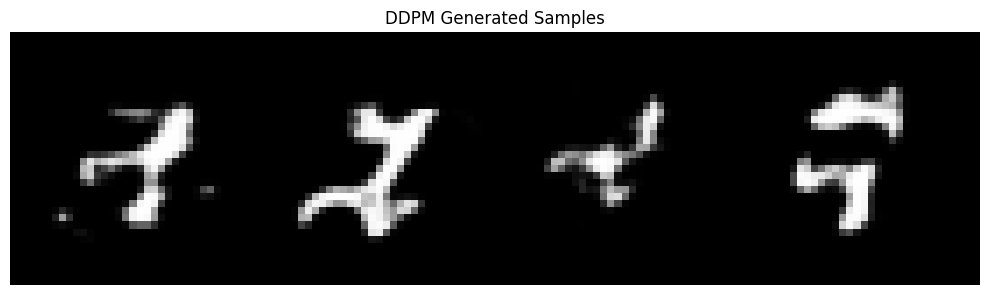

In [14]:
sampler = model_ddpm


# Cell 4: Test and Benchmark

# Generate samples
z_noise = torch.randn(4, 16, 8, 8, device=device)
x_samples = sampler.sample(z_noise, torch.tensor([3]).to(device), t_steps=1000, verbose=True)


# Benchmark
# result = benchmark(sampler, batch_size=4, t_steps=50, num_runs=2)
# print(f"\nDDPM 50 steps: {result['mean_time_s']:.2f}s ± {result['std_time_s']:.2f}s")

# # Visualize
visualize_samples(x_samples, title="DDPM Generated Samples")

In [22]:
import matplotlib.pyplot as plt
def visualize_reconstruction(vae, sampler, test_loader, device='cuda', num_samples=16):
    """Side-by-side original and reconstructed images"""
    # vae.eval()

    x_test, x_label = next(iter(test_loader))
    x_test = x_test[:num_samples].to(device)
    x_label = x_label[:num_samples].to(device)

    with torch.no_grad():
        z_noise = vae.encode_only(x_test)

        x_recon = sampler.sample(z_noise, x_label, t_steps=1000, verbose=True)

    x_test_viz = (x_test.cpu() + 1) / 2
    x_recon_viz = (x_recon.cpu() + 1) / 2

    fig, axes = plt.subplots(2, num_samples // 2, figsize=(16, 6))
    fig.suptitle('VAE Reconstruction Comparison', fontsize=16)

    idx = 0
    for i in range(1):
        for j in range(num_samples // 2):
            axes[i, j].imshow(x_test_viz[idx].permute(1, 2, 0).numpy())
            axes[i, j].set_title(f"{'Original'} {idx}")
            axes[i, j].axis('off')
            idx += 1

        idx = 0
        for j in range(num_samples // 2):
            axes[i+1, j].imshow(x_recon_viz[idx].permute(1, 2, 0).numpy())
            axes[i+1, j].set_title(f"{'Reconstructed'} {idx}")
            axes[i+1, j].axis('off')
            idx += 1

    plt.tight_layout()
    plt.show()

In [23]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Pad(2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


DDPM: 100%|██████████| 1000/1000 [00:10<00:00, 95.84it/s]


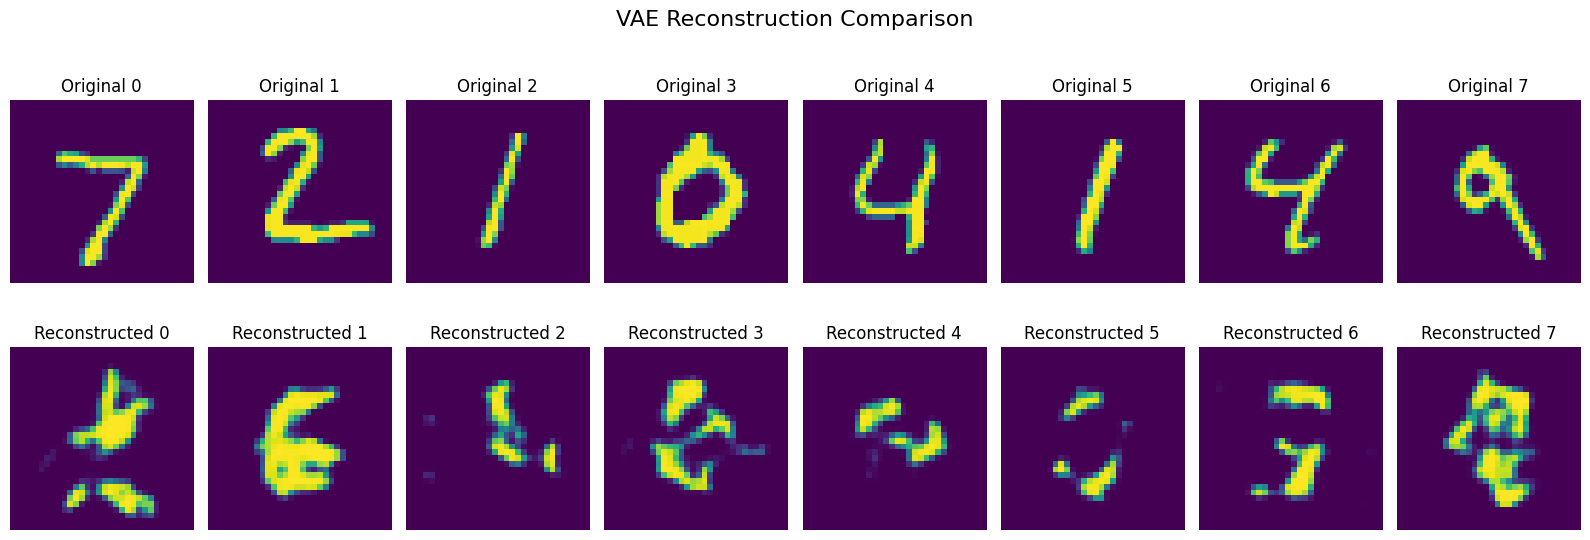

In [24]:
sampler.model = sampler.model.to(device=device)
visualize_reconstruction(vae.to(device=device), sampler, test_loader)